#### Importing Libraries

In [350]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [351]:
df = pd.DataFrame()

In [352]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['Label'] = [1,1,0,1,0,1,0,1,0,0]

In [353]:
df

,X1,X2,Label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

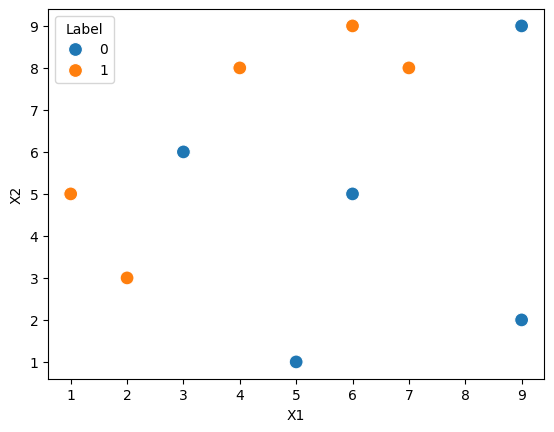

In [354]:
sns.scatterplot(data=df, x='X1', y='X2', hue='Label', s=100)

In [355]:
df['weights'] = 1/df.shape[0]

In [356]:
df

,X1,X2,Label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [357]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [358]:
x = df[['X1','X2']].values
y = df['Label'].values

In [359]:
dt1.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

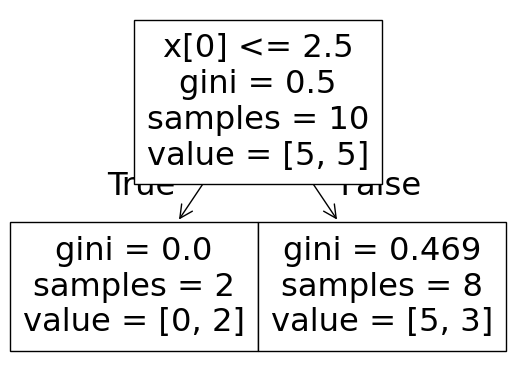

In [360]:
plot_tree(dt1)

<Axes: >

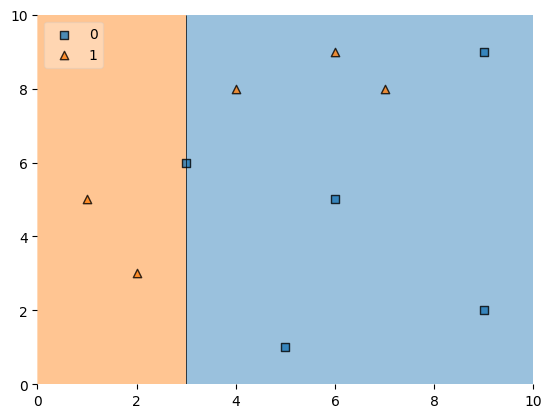

In [361]:
plot_decision_regions(X=x, y=y, clf=dt1, legend=2)

In [362]:
df['y_pred'] = dt1.predict(x)

In [363]:
df

,X1,X2,Label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [364]:
def calculate_model_weight(error):
    return 0.5 * np.log((1 - error) / (error + 1e-10))

In [365]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893002693516)

In [366]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['Label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [367]:
df['updated_weights'] = df.apply(update_row_weights , axis=1)

In [368]:
df

,X1,X2,Label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [369]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

The sum should equal to 1 , so now we we'll Normalise

In [370]:
df['normalised_weights'] = df['updated_weights'] / df['updated_weights'].sum()

In [371]:
df

,X1,X2,Label,weights,y_pred,updated_weights,normalised_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [372]:
df['normalised_weights'].sum()

np.float64(1.0)

In [373]:
df['cumsum_upper'] = np.cumsum(df['normalised_weights'])

In [374]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalised_weights']

In [375]:
df[['X1','X2','Label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,Label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [376]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [377]:
index_values = create_new_dataset(df)

index_values

[0, 2, 0, 0, 4, 9, 7, 1, 0, 2]

In [378]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [379]:
second_df

,X1,X2,Label,weights
0,1,5,1,0.1
2,3,6,0,0.1
0,1,5,1,0.1
0,1,5,1,0.1
4,5,1,0,0.1
9,9,2,0,0.1
7,7,8,1,0.1
1,2,3,1,0.1
0,1,5,1,0.1
2,3,6,0,0.1


In [380]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [381]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [382]:
dt2.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.625, 0.5, '  False')]

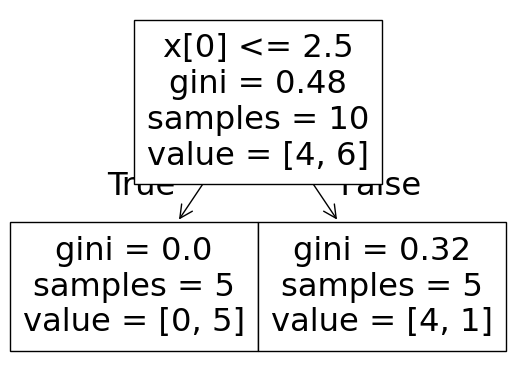

In [383]:
plot_tree(dt2)

<Axes: >

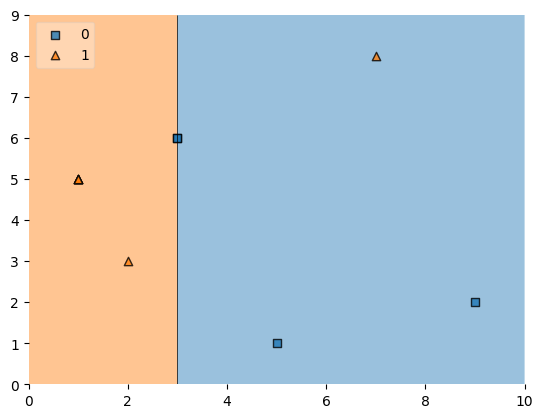

In [384]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [385]:
second_df['y_pred'] = dt2.predict(X)

In [386]:
second_df

,X1,X2,Label,weights,y_pred
0,1,5,1,0.1,1
2,3,6,0,0.1,0
0,1,5,1,0.1,1
0,1,5,1,0.1,1
4,5,1,0,0.1,0
9,9,2,0,0.1,0
7,7,8,1,0.1,0
1,2,3,1,0.1,1
0,1,5,1,0.1,1
2,3,6,0,0.1,0


In [387]:
alpha2 = calculate_model_weight(0.1)

In [388]:
alpha2

np.float64(1.0986122881681097)

In [389]:
def update_row_weights(row,alpha=1.09):
  if row['Label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [390]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [391]:
second_df

,X1,X2,Label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622
0,1,5,1,0.1,1,0.033622
0,1,5,1,0.1,1,0.033622
4,5,1,0,0.1,0,0.033622
9,9,2,0,0.1,0,0.033622
7,7,8,1,0.1,0,0.297427
1,2,3,1,0.1,1,0.033622
0,1,5,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622


In [392]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [393]:
second_df

,X1,X2,Label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.033622,0.056034
2,3,6,0,0.1,0,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,0,0.297427,0.495694
1,2,3,1,0.1,1,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
2,3,6,0,0.1,0,0.033622,0.056034


In [394]:
second_df['nomalized_weights'].sum()

np.float64(0.9999999999999999)

In [395]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [396]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [397]:
second_df[['X1','X2','Label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,Label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.056034,0.000000,0.056034
2,3,6,0,0.1,0,0.056034,0.056034,0.112068
0,1,5,1,0.1,1,0.056034,0.112068,0.168102
0,1,5,1,0.1,1,0.056034,0.168102,0.224136
4,5,1,0,0.1,0,0.056034,0.224136,0.280170
9,9,2,0,0.1,0,0.056034,0.280170,0.336204
7,7,8,1,0.1,0,0.495694,0.336204,0.831898
1,2,3,1,0.1,1,0.056034,0.831898,0.887932
0,1,5,1,0.1,1,0.056034,0.887932,0.943966
2,3,6,0,0.1,0,0.056034,0.943966,1.000000


In [398]:
index_values = create_new_dataset(second_df)

In [399]:
index_values = create_new_dataset(second_df)

In [400]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [401]:
third_df

,X1,X2,Label,weights
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
0,1,5,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1


In [402]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

<Axes: >

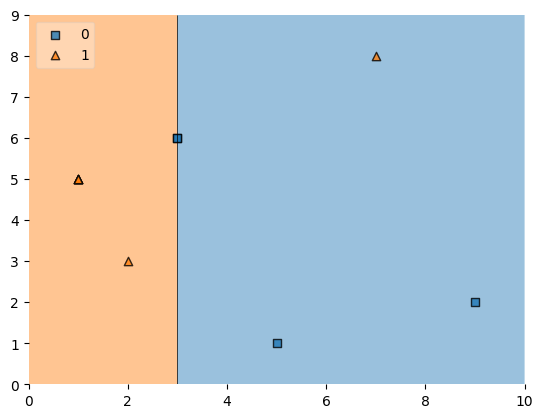

In [403]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [404]:
third_df['y_pred'] = dt3.predict(X)

In [405]:
third_df

,X1,X2,Label,weights,y_pred
1,2,3,1,0.1,1
1,2,3,1,0.1,0
1,2,3,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,0
1,2,3,1,0.1,0
0,1,5,1,0.1,0
1,2,3,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,0


In [406]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.42364893026503025)

In [407]:
print(alpha1,alpha2,alpha3)

0.42364893002693516 1.0986122881681097 -0.42364893026503025


### Pridiction

In [408]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [409]:
dt2.predict(query)

array([1])

In [410]:
dt3.predict(query)

array([1])

In [411]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.0986122879300146)

In [412]:
np.sign(1.09)

np.float64(1.0)

In [413]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [414]:
dt2.predict(query)

array([0])

In [415]:
dt3.predict(query)

array([0])

In [416]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(-0.25131442787614433)

In [417]:
np.sign(-0.25)

np.float64(-1.0)